In [ ]:
!pip install unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 8.2 MB/s eta 0:00:00


In [ ]:

!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 51.5 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import re
import random
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import time
import os
from rdkit import Chem
from rdkit.Chem import AllChem
from collections import Counter, OrderedDict
import warnings
warnings.filterwarnings('ignore')

In [ ]:
class FunctionalGroupTokenizer:

    def __init__(self):
        self.functional_groups = OrderedDict([
            # Complex rings
            ('[FG_PIPERIDINE]', 'C1CCNCC1'),
            ('[FG_PIPERAZINE]', 'C1CNCCN1'),
            ('[FG_MORPHOLINE]', 'C1COCCN1'),
            ('[FG_PYRROLIDINE]', 'C1CCNC1'),
            ('[FG_IMIDAZOLE]', 'c1c[nH]cn1'),
            ('[FG_PYRIDINE]', 'n1ccccc1'),
            ('[FG_PYRIMIDINE]', 'c1ncncn1'),
            ('[FG_BENZENE]', 'c1ccccc1'),
            ('[FG_FURAN]', 'o1cccc1'),
            ('[FG_THIOPHENE]', 's1cccc1'),

            # Functional groups
            ('[FG_CARBOXYL]', 'C(=O)[OH]'),
            ('[FG_ESTER]', 'C(=O)O[C]'),
            ('[FG_AMIDE]', 'C(=O)N'),
            ('[FG_SULFONAMIDE]', 'S(=O)(=O)N'),
            ('[FG_SULFONE]', 'S(=O)(=O)'),
            ('[FG_NITRO]', '[N+](=O)[O-]'),
            ('[FG_NITRILE]', 'C#N'),
            ('[FG_ALDEHYDE]', 'C(=O)[H]'),
            ('[FG_KETONE]', '[C](=O)[C]'),
            ('[FG_ALCOHOL]', '[C][OH]'),
            ('[FG_PHENOL]', 'c[OH]'),
            ('[FG_ETHER]', '[C]O[C]'),
            ('[FG_AMINE_1]', '[C]N([H])[H]'),
            ('[FG_AMINE_2]', '[C]N([H])[C]'),
            ('[FG_AMINE_3]', '[C]N([C])[C]'),
            ('[FG_THIOL]', '[C][SH]'),
            ('[FG_SULFIDE]', '[C]S[C]'),
        ])

        # Compile SMARTS patterns
        self.smarts_patterns = {}
        print("Compiling SMARTS patterns...")
        compiled_count = 0
        for token, smarts in self.functional_groups.items():
            try:
                pattern = Chem.MolFromSmarts(smarts)
                if pattern:
                    self.smarts_patterns[token] = pattern
                    compiled_count += 1
            except Exception as e:
                print(f"Failed to compile {token}: {e}")

        print(f"Compiled {compiled_count}/{len(self.functional_groups)} patterns")

        # Character-level tokenization patterns
        self.char_patterns = [
            r'\[nH\]', r'\[NH\]', r'\[NH2\]', r'\[NH3\+\]',
            r'\[N\+\]', r'\[N-\]', r'\[N\]',
            r'\[O-\]', r'\[OH\]', r'\[O\]',
            r'\[S\+\]', r'\[SH\]', r'\[S\]',
            r'\[Se\]', r'\[Si\]', r'\[P\]', r'\[B\]',
            r'\[Cl\]', r'\[Br\]', r'\[I\]', r'\[F\]',
            r'\[C@@H\]', r'\[C@H\]', r'\[C@@\]', r'\[C@\]', r'\[CH\]',
            r'Cl', r'Br',
            r'%\d{2}', r'\d',
            r'\(', r'\)', r'\[', r'\]', r'=', r'#', r'/', r'\\', r'\.',
            r'[CNOSPFIBcnops]',
        ]
        self.char_regex = re.compile('|'.join(self.char_patterns))

        # Add functional group tokens to char patterns for tokenization
        self.all_patterns = [re.escape(fg) for fg in self.functional_groups.keys()] + self.char_patterns
        self.full_regex = re.compile('|'.join(self.all_patterns))

        self.vocab = []
        self.stoi = {}
        self.itos = {}
        self.vocab_size = 0

    def identify_functional_groups(self, smiles):
        """Identify functional groups and return FG tokens + original SMILES"""
        # Parse molecule
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return [], smiles  # Return empty FG list if parsing fails

        # Find all functional group matches
        fg_found = set()
        for fg_token, pattern in self.smarts_patterns.items():
            if mol.HasSubstructMatch(pattern):
                fg_found.add(fg_token)

        return sorted(list(fg_found)), smiles

    def tokenize_smiles(self, smiles):
        """Tokenize SMILES string (basic character-level)"""
        tokens = self.char_regex.findall(smiles)
        return tokens

    def tokenize_with_fg(self, smiles):
        """Tokenize with functional group tokens prepended"""
        fg_tokens, original_smiles = self.identify_functional_groups(smiles)
        smiles_tokens = self.tokenize_smiles(original_smiles)
        return fg_tokens + smiles_tokens

    def build_vocab(self, text):
        """Build vocabulary from dataset"""
        print("\n🔧 Building vocabulary...")

        # Split into molecules (assuming format: <SMILES>)
        molecules = []
        for mol in text.strip().split('>'):
            mol = mol.strip().strip('<')
            if mol:
                molecules.append(mol)

        print(f"📊 Processing {len(molecules):,} molecules...")

        # Tokenize all molecules
        all_tokens = []
        sample_size = min(100000, len(molecules))

        for i, mol in enumerate(molecules[:sample_size]):
            if i % 10000 == 0 and i > 0:
                print(f"  Processed {i:,} molecules...")

            try:
                tokens = self.tokenize_with_fg(mol)
                all_tokens.extend(tokens)
            except Exception as e:
                # Fallback to simple tokenization
                tokens = self.tokenize_smiles(mol)
                all_tokens.extend(tokens)

        print(f"✅ Tokenized {sample_size:,} molecules")

        # Count token frequencies
        token_counts = Counter(all_tokens)

        # Create vocabulary: special tokens + FG tokens + regular tokens
        special_tokens = ['<PAD>', '<UNK>', '<START>', '<END>']
        fg_tokens = list(self.functional_groups.keys())
        regular_tokens = [token for token, _ in token_counts.most_common()
                         if token not in fg_tokens]

        self.vocab = special_tokens + fg_tokens + regular_tokens
        self.vocab_size = len(self.vocab)

        # Create mappings
        self.stoi = {token: i for i, token in enumerate(self.vocab)}
        self.itos = {i: token for i, token in enumerate(self.vocab)}

        print(f"✅ Vocabulary built: {self.vocab_size} unique tokens")
        print(f"   - Special tokens: {len(special_tokens)}")
        print(f"   - Functional groups: {len(fg_tokens)}")
        print(f"   - Regular tokens: {len(regular_tokens)}")
        print(f"\n📊 Most common regular tokens: {token_counts.most_common(20)}")

        return self.vocab_size

    def encode(self, smiles):
        """Encode SMILES string with functional group identification"""
        fg_tokens, original_smiles = self.identify_functional_groups(smiles)
        smiles_tokens = self.tokenize_smiles(original_smiles)
        all_tokens = fg_tokens + smiles_tokens
        return [self.stoi.get(token, self.stoi['<UNK>']) for token in all_tokens]

    def decode(self, indices):
        """Decode token indices back to SMILES (removes FG tokens)"""
        tokens = [self.itos.get(i, '<UNK>') for i in indices]
        # Filter out functional group tokens and special tokens
        fg_tokens = set(self.functional_groups.keys())
        special_tokens = {'<PAD>', '<UNK>', '<START>', '<END>'}
        filtered_tokens = [t for t in tokens if t not in fg_tokens and t not in special_tokens]
        return ''.join(filtered_tokens)

    def get_fg_tokens(self, indices):
        """Extract functional group tokens from encoded sequence"""
        tokens = [self.itos.get(i, '<UNK>') for i in indices]
        fg_tokens = set(self.functional_groups.keys())
        return [t for t in tokens if t in fg_tokens]

In [ ]:
# LOAD AND PREPROCESS DATA
try:
    with open('/content/drive/MyDrive/tokenization/data_for_generation_mol.txt', 'r') as f:
        text = f.read()
    print(f"✅ Data loaded successfully")
except:
    print("⚠️ Data file not found. Using sample data...")


print(f"📊 Total characters: {len(text):,}")
print(f"🧬 Number of molecules: {text.count('<'):,}")
print(f"🔤 First 200 chars: {text[:200]}")


✅ Data loaded successfully
📊 Total characters: 75,602,998
🧬 Number of molecules: 1,498,669
🔤 First 200 chars: <COc1ccc2[C@@H]3[C@H](COc2c1)C(C)(C)OC4=C3C(=O)C(=O)C5=C4OC(C)(C)[C@@H]6COc7cc(OC)ccc7[C@H]56><C[S+]([O-])c1ccc(cc1)c2nc(c3ccc(F)cc3)c([nH]2)c4ccncc4><CC1(C)Oc2ccc(cc2[C@H]([C@@H]1O)N3CCCC3=O)C#N><OC(


In [ ]:
# BUILD TOKENIZER
tokenizer = FunctionalGroupTokenizer()
vocab_size = tokenizer.build_vocab(text)

print(f"\n📏 Final vocabulary size: {vocab_size}")


Compiling SMARTS patterns...
Compiled 27/27 patterns

🔧 Building vocabulary...
📊 Processing 1,498,669 molecules...
  Processed 10,000 molecules...
  Processed 20,000 molecules...
  Processed 30,000 molecules...
  Processed 40,000 molecules...
  Processed 50,000 molecules...
  Processed 60,000 molecules...
  Processed 70,000 molecules...


[19:37:58] Explicit valence for atom # 13 N, 4, is greater than permitted


  Processed 80,000 molecules...
  Processed 90,000 molecules...
✅ Tokenized 100,000 molecules
✅ Vocabulary built: 79 unique tokens
   - Special tokens: 4
   - Functional groups: 27
   - Regular tokens: 48

📊 Most common regular tokens: [('c', 1118527), ('C', 880830), ('(', 459707), (')', 459707), ('O', 294807), ('=', 197450), ('1', 194230), ('N', 184761), ('2', 178473), ('3', 144751), ('n', 86745), ('4', 86290), ('[FG_BENZENE]', 83394), ('[FG_KETONE]', 43427), ('[FG_AMIDE]', 40390), ('F', 35988), ('5', 34542), ('\\', 33990), ('[FG_AMINE_3]', 32264), ('[C@H]', 32053)]

📏 Final vocabulary size: 79


In [ ]:
print(f"\n{'=' * 70}")
print("📄 Encoding entire dataset with proper structure...")
print("=" * 70)

# Split into molecules
molecules = []
for mol in text.strip().split('>'):
    mol = mol.strip().strip('<')
    if mol:
        molecules.append(mol)

print(f"📊 Total molecules: {len(molecules):,}")

# Encode each molecule as: <START> [FG_TOKENS] SMILES <END>
all_sequences = []
encode_failed = 0

for i, mol in enumerate(molecules):
    if i % 50000 == 0 and i > 0:
        print(f"  Processed {i:,} molecules...")

    try:
        # Create sequence: <START> + [FG tokens + SMILES] + <END>
        sequence = [tokenizer.stoi['<START>']]  # Start token
        sequence.extend(tokenizer.encode(mol))   # FG tokens + SMILES
        sequence.append(tokenizer.stoi['<END>']) # End token

        all_sequences.append(sequence)
    except Exception as e:
        encode_failed += 1

print(f"✅ Encoded {len(all_sequences):,} molecules ({encode_failed} failed)")

# Flatten all sequences into one long tensor
data = torch.tensor([token for seq in all_sequences for token in seq], dtype=torch.long)

print(f"📊 Dataset shape: {data.shape}")
print(f"📊 Total tokens: {len(data):,}")

# Verify structure
print("\n🔍 Verifying data structure:")
print(f"First 50 token IDs: {data[:50].tolist()}")
print(f"First 50 tokens: {[tokenizer.itos[i] for i in data[:50].tolist()]}")

# Check first 3 molecules
print("\n🔍 First 3 molecules in dataset:")
token_idx = 0
for i in range(3):
    # Find next <END> token
    end_positions = (data[token_idx:] == tokenizer.stoi['<END>']).nonzero(as_tuple=True)[0]
    if len(end_positions) > 0:
        end_idx = end_positions[0].item() + token_idx
        sequence = data[token_idx:end_idx+1].tolist()
        tokens = [tokenizer.itos[idx] for idx in sequence]

        print(f"\nMolecule {i+1}:")
        print(f"  Length: {len(sequence)} tokens")
        print(f"  First tokens: {tokens[:10]}")
        print(f"  Last tokens: {tokens[-5:]}")
        print(f"  Decoded: {tokenizer.decode(sequence)[:80]}...")  # First 80 chars

        token_idx = end_idx + 1
    else:
        break

print(f"\n{'=' * 70}")
print("✅ DATA ENCODING COMPLETE!")
print("=" * 70)


📄 Encoding entire dataset with proper structure...
📊 Total molecules: 1,498,669
  Processed 50,000 molecules...


[19:38:40] Explicit valence for atom # 13 N, 4, is greater than permitted


  Processed 100,000 molecules...


[19:39:02] Conflicting single bond directions around double bond at index 6.
[19:39:02]   BondStereo set to STEREONONE and single bond directions set to NONE.


  Processed 150,000 molecules...
  Processed 200,000 molecules...
  Processed 250,000 molecules...
  Processed 300,000 molecules...
  Processed 350,000 molecules...
  Processed 400,000 molecules...
  Processed 450,000 molecules...
  Processed 500,000 molecules...
  Processed 550,000 molecules...
  Processed 600,000 molecules...


...

  Processed 1,150,000 molecules...
  Processed 1,200,000 molecules...


[19:46:41] Explicit valence for atom # 1 C, 5, is greater than permitted
[19:46:46] Explicit valence for atom # 2 O, 2, is greater than permitted
[19:46:46] Explicit valence for atom # 6 O, 2, is greater than permitted
[19:46:46] Explicit valence for atom # 8 O, 2, is greater than permitted


  Processed 1,250,000 molecules...
  Processed 1,300,000 molecules...


[19:47:23] Explicit valence for atom # 4 N, 5, is greater than permitted
[19:47:41] Conflicting single bond directions around double bond at index 5.
[19:47:41]   BondStereo set to STEREONONE and single bond directions set to NONE.
[19:47:42] Conflicting single bond directions around double bond at index 5.
[19:47:42]   BondStereo set to STEREONONE and single bond directions set to NONE.


  Processed 1,350,000 molecules...
  Processed 1,400,000 molecules...
  Processed 1,450,000 molecules...
✅ Encoded 1,498,669 molecules (0 failed)
📊 Dataset shape: torch.Size([76521071])
📊 Total tokens: 76,521,071

🔍 Verifying data structure:
First 50 token IDs: [2, 11, 25, 22, 32, 35, 31, 37, 31, 31, 31, 39, 47, 40, 46, 33, 32, 35, 31, 39, 31, 37, 34, 32, 33, 32, 34, 33, 32, 34, 35, 32, 42, 36, 32, 40, 32, 33, 36, 35, 34, 32, 33, 36, 35, 34, 32, 44, 36, 32]
First 50 tokens: ['<START>', '[FG_BENZENE]', '[FG_ETHER]', '[FG_KETONE]', 'C', 'O', 'c', '1', 'c', 'c', 'c', '2', '[C@@H]', '3', '[C@H]', '(', 'C', 'O', 'c', '2', 'c', '1', ')', 'C', '(', 'C', ')', '(', 'C', ')', 'O', 'C', '4', '=', 'C', '3', 'C', '(', '=', 'O', ')', 'C', '(', '=', 'O', ')', 'C', '5', '=', 'C']

🔍 First 3 molecules in dataset:

Molecule 1:
  Length: 79 tokens
  First tokens: ['<START>', '[FG_BENZENE]', '[FG_ETHER]', '[FG_KETONE]', 'C', 'O', 'c', '1', 'c', 'c']
  Last tokens: ['7', '[C@H]', '5', '6', '<END>']
  Decod

In [ ]:
# Verify the structure is correct
print("\n🔍 Verifying data structure:")
print(f"First 50 tokens: {data[:50].tolist()}")
print(f"First 50 decoded: {[tokenizer.itos[i] for i in data[:50].tolist()]}")

# Check first 3 molecules
print("\n🔍 Checking first 3 molecules:")
token_idx = 0
for i in range(3):
    # Find next <END> token
    end_positions = (data[token_idx:] == tokenizer.stoi['<END>']).nonzero(as_tuple=True)[0]
    if len(end_positions) > 0:
        end_idx = end_positions[0].item() + token_idx
        sequence = data[token_idx:end_idx+1].tolist()
        tokens = [tokenizer.itos[idx] for idx in sequence]

        print(f"\nMolecule {i+1}:")
        print(f"  Tokens: {tokens[:15]}...")  # First 15 tokens
        print(f"  Decoded: {tokenizer.decode(sequence)}")

        token_idx = end_idx + 1
    else:
        break


🔍 Verifying data structure:
First 50 tokens: [2, 11, 25, 22, 32, 35, 31, 37, 31, 31, 31, 39, 47, 40, 46, 33, 32, 35, 31, 39, 31, 37, 34, 32, 33, 32, 34, 33, 32, 34, 35, 32, 42, 36, 32, 40, 32, 33, 36, 35, 34, 32, 33, 36, 35, 34, 32, 44, 36, 32]
First 50 decoded: ['<START>', '[FG_BENZENE]', '[FG_ETHER]', '[FG_KETONE]', 'C', 'O', 'c', '1', 'c', 'c', 'c', '2', '[C@@H]', '3', '[C@H]', '(', 'C', 'O', 'c', '2', 'c', '1', ')', 'C', '(', 'C', ')', '(', 'C', ')', 'O', 'C', '4', '=', 'C', '3', 'C', '(', '=', 'O', ')', 'C', '(', '=', 'O', ')', 'C', '5', '=', 'C']

🔍 Checking first 3 molecules:

Molecule 1:
  Tokens: ['<START>', '[FG_BENZENE]', '[FG_ETHER]', '[FG_KETONE]', 'C', 'O', 'c', '1', 'c', 'c', 'c', '2', '[C@@H]', '3', '[C@H]']...
  Decoded: COc1ccc2[C@@H]3[C@H](COc2c1)C(C)(C)OC4=C3C(=O)C(=O)C5=C4OC(C)(C)[C@@H]6COc7cc(OC)ccc7[C@H]56

Molecule 2:
  Tokens: ['<START>', '[FG_BENZENE]', '[FG_IMIDAZOLE]', '[FG_PYRIDINE]', 'C', '[S+]', '(', '[O-]', ')', 'c', '1', 'c', 'c', 'c', '(']...
  Decode

## Data Splitting and Batch Generation

In [ ]:
# Improved hyperparameters
batch_size = 32        # Increased batch size for better gradients
block_size = 256       # Increased context length for better SMILES learning
learning_rate = 1e-4   # Better learning rate
n_head = 12             # Reduced for efficiency
n_embd = n_head * 32    # Reasonable embedding size (384)
ff_size_factor = 4     # Standard transformer ratio
n_layer = 12            # Sufficient depth
dropout = 0.15          # Regularization

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥️ Using device: {device}")

🖥️ Using device: cuda


In [ ]:
import torch

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU found - will use CPU")


CUDA available: True
GPU name: Tesla T4
GPU memory: 15.8 GB


In [ ]:
# Split data into train/validation
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]
print(f"📊 Train data: {len(train_data):,} tokens")
print(f"📊 Val data: {len(val_data):,} tokens")

📊 Train data: 68,868,963 tokens
📊 Val data: 7,652,108 tokens


In [ ]:
def get_batch(split):
    """Generate a batch of training data"""
    data_split = train_data if split == 'train' else val_data
    ix = torch.randint(len(data_split) - block_size, (batch_size,))
    x = torch.stack([data_split[i:i+block_size] for i in ix])
    y = torch.stack([data_split[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

# Test batch generation
xb, yb = get_batch('train')
print(f"\n🔢 Batch shapes:")
print(f"Input (x): {xb.shape}")
print(f"Target (y): {yb.shape}")

# Show example of training sequences
print(f"\n📝 Sample training sequences:")
for i in range(min(3, batch_size)):
    sample_x = tokenizer.decode(xb[i][:20].cpu().tolist())
    sample_y = tokenizer.decode(yb[i][:20].cpu().tolist())
    print(f"Sequence {i+1}:")
    print(f"  Input:  '{sample_x}'")
    print(f"  Target: '{sample_y}'")


🔢 Batch shapes:
Input (x): torch.Size([32, 256])
Target (y): torch.Size([32, 256])

📝 Sample training sequences:
Sequence 1:
  Input:  'CCCCC(=O)C(CCCC'
  Target: 'CCCC(=O)C(CCCCC'
Sequence 2:
  Input:  '(C(=O)N[C@H](C(=O)N(C)[C@H]('
  Target: 'C(=O)N[C@H](C(=O)N(C)[C@H](\'
Sequence 3:
  Input:  'Fc1ccccc1[C@@H]2[C@@H]3CCCN[C@@H]3c'
  Target: 'c1ccccc1[C@@H]2[C@@H]3CCCN[C@@H]3c4'


In [ ]:
# Model Architecture

class Head(nn.Module):
    """Single head of self-attention with improvements"""

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)
        self.head_size = head_size

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        v = self.value(x)

        # Scaled dot-product attention with proper scaling
        wei = q @ k.transpose(-2, -1) * (self.head_size ** -0.5)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)

        out = wei @ v
        return out

class MultiHeadAttention(nn.Module):
    """Multi-head attention with residual connection"""

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedForward(nn.Module):
    """Feed-forward network with GELU activation"""

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, ff_size_factor * n_embd),
            nn.GELU(),
            nn.Linear(ff_size_factor * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """Transformer block with pre-layer normalization"""

    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        # Pre-layer normalization (better for training stability)
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class DrugGPT(nn.Module):
    """Improved DrugGPT model for SMILES generation"""

    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

        # Initialize weights
        self.apply(self._init_weights)

    def _init_weights(self, module):
        """Initialize weights for better training"""
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens, eos_token, temperature=1.0, top_k=None):
        """Improved generation with temperature and top-k sampling"""
        self.eval()  # Set to evaluation mode

        with torch.no_grad():
            for _ in range(max_new_tokens):
                # Crop context to block_size
                idx_cond = idx[:, -block_size:]

                # Get predictions
                logits, _ = self(idx_cond)
                logits = logits[:, -1, :] / temperature

                # Apply top-k filtering if specified
                if top_k is not None:
                    v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                    logits[logits < v[:, [-1]]] = -float('Inf')

                # Sample from the distribution
                probs = F.softmax(logits, dim=-1)
                idx_next = torch.multinomial(probs, num_samples=1)

                # Check for end-of-sequence token
                if idx_next.item() == eos_token:
                    break

                # Append to sequence
                idx = torch.cat((idx, idx_next), dim=1)

        self.train()  # Back to training mode
        return idx

# Create and initialize model
model = DrugGPT()
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"🔧 Model created successfully!")
print(f"📊 Total parameters: {total_params/1e6:.2f}M")
print(f"🏋️ Trainable parameters: {trainable_params/1e6:.2f}M")
print(f"💾 Model size: ~{total_params * 4 / 1e6:.1f}MB")

🔧 Model created successfully!
📊 Total parameters: 21.44M
🏋️ Trainable parameters: 21.44M
💾 Model size: ~85.8MB


In [ ]:
# Training Setup and Loss Estimation

# Training hyperparameters
max_iters = 10000
eval_interval = 200
eval_iters = 100
save_interval = 500
save_path = "/content/drive/MyDrive/tokenization/improved_drugGPT.pt"

# Optimizer with weight decay for regularization
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_iters, eta_min=learning_rate*0.1)

@torch.no_grad()
def estimate_loss():
    """Estimate loss on train and validation sets"""
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

def validate_smiles(smiles_list):
    """Validate SMILES strings using RDKit"""
    valid_smiles = []
    for smi in smiles_list:
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol is not None:
                # Additional validation: check if it can be converted back
                canonical_smi = Chem.MolToSmiles(mol)
                if canonical_smi:
                    valid_smiles.append(canonical_smi)
        except:
            continue
    return valid_smiles

def generate(self, idx, max_new_tokens, eos_token=None, temperature=1.0, top_k=None):
    """
    Generate new tokens given a context

    Args:
        idx: (B, T) tensor of indices
        max_new_tokens: number of tokens to generate
        eos_token: token ID to stop generation (optional)
        temperature: sampling temperature
        top_k: if set, only sample from top k tokens
    """
    for _ in range(max_new_tokens):
        # Crop context to block_size
        idx_cond = idx if idx.size(1) <= self.block_size else idx[:, -self.block_size:]

        # Get predictions
        logits, _ = self(idx_cond)

        # Focus on last time step
        logits = logits[:, -1, :] / temperature

        # Optional: top-k sampling
        if top_k is not None:
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = -float('Inf')

        # Apply softmax to get probabilities
        probs = F.softmax(logits, dim=-1)

        # Sample from distribution
        idx_next = torch.multinomial(probs, num_samples=1)

        # Append to sequence
        idx = torch.cat((idx, idx_next), dim=1)

        # Stop if we hit EOS token
        if eos_token is not None and idx_next.item() == eos_token:
            break

    return idx

print("✅ Training functions ready!")

✅ Training functions ready!


🚀 Starting training for 10000 iterations...
📊 Batch size: 32, Block size: 256
🧠 Model: 21.4M parameters
Step    0 | Train: 3.3921 | Val: 3.3805 | LR: 1.00e-04 | Time: 37.0s
💾 Checkpoint saved at iteration 0
Step  200 | Train: 1.6452 | Val: 1.6881 | LR: 9.99e-05 | Time: 200.2s
Step  400 | Train: 1.4313 | Val: 1.4780 | LR: 9.96e-05 | Time: 362.2s
💾 Checkpoint saved at iteration 500
Step  600 | Train: 1.1903 | Val: 1.2425 | LR: 9.92e-05 | Time: 525.9s
Step  800 | Train: 1.0854 | Val: 1.1380 | LR: 9.86e-05 | Time: 688.4s
Step 1000 | Train: 1.0200 | Val: 1.0675 | LR: 9.78e-05 | Time: 850.7s
💾 Checkpoint saved at iteration 1000
Step 1200 | Train: 0.9716 | Val: 1.0243 | LR: 9.68e-05 | Time: 1019.0s
Step 1400 | Train: 0.9443 | Val: 0.9928 | LR: 9.57e-05 | Time: 1181.3s
💾 Checkpoint saved at iteration 1500
Step 1600 | Train: 0.9132 | Val: 0.9623 | LR: 9.44e-05 | Time: 1345.0s
Step 1800 | Train: 0.8793 | Val: 0.9274 | LR: 9.30e-05 | Time: 1507.5s
Step 2000 | Train: 0.8503 | Val: 0.9004 | LR: 9.1

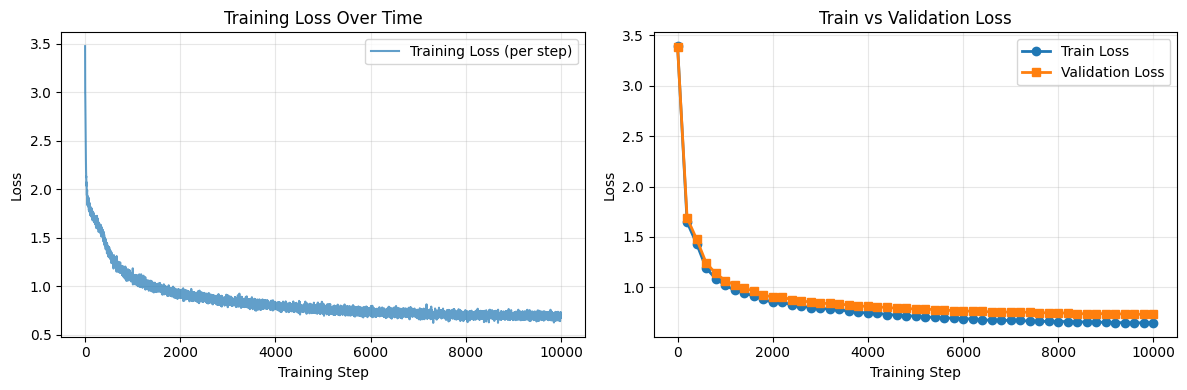

📊 Final Training Loss: 0.6505
📊 Final Validation Loss: 0.7324


In [ ]:
# Training Loop

# Check for existing checkpoint
resume_training = os.path.exists(save_path)
start_iter = 0

if resume_training:
    print(f"🔄 Resuming from checkpoint: {save_path}")
    try:
        checkpoint = torch.load(save_path, map_location=device)
        if isinstance(checkpoint, dict):
            model.load_state_dict(checkpoint['model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            start_iter = checkpoint.get('iteration', 0)
            print(f"📍 Resuming from iteration {start_iter}")
        else:
            # Legacy: whole model saved
            model = checkpoint
            model.to(device)
            print("📍 Loaded legacy checkpoint")
    except Exception as e:
        print(f"⚠️ Error loading checkpoint: {e}")
        print("🔄 Starting fresh training...")
        resume_training = False

# Training variables
losses = []
train_losses = []
val_losses = []
start_time = time.time()

print(f"🚀 Starting training for {max_iters} iterations...")
print(f"📊 Batch size: {batch_size}, Block size: {block_size}")
print(f"🧠 Model: {trainable_params/1e6:.1f}M parameters")

# Training loop
for iter_num in range(start_iter, max_iters):

    # Evaluate losses periodically
    if iter_num % eval_interval == 0 or iter_num == max_iters - 1:
        losses_dict = estimate_loss()
        train_loss = losses_dict['train']
        val_loss = losses_dict['val']

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        elapsed_time = time.time() - start_time
        current_lr = optimizer.param_groups[0]['lr']

        print(f"Step {iter_num:4d} | "
              f"Train: {train_loss:.4f} | "
              f"Val: {val_loss:.4f} | "
              f"LR: {current_lr:.2e} | "
              f"Time: {elapsed_time:.1f}s")

    # Training step
    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()

    # Gradient clipping for stability
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer.step()
    scheduler.step()

    losses.append(loss.item())

    # Save checkpoint
    if iter_num % save_interval == 0 or iter_num == max_iters - 1:
        checkpoint = {
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'iteration': iter_num,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'config': {
                'vocab_size': vocab_size,
                'block_size': block_size,
                'n_embd': n_embd,
                'n_head': n_head,
                'n_layer': n_layer,
                'dropout': dropout
            }
        }
        torch.save(checkpoint, save_path)
        # torch.save(model.state_dict(), save_path)
        print(f"💾 Checkpoint saved at iteration {iter_num}")

total_time = time.time() - start_time
print(f"\n✅ Training completed!")
print(f"⏱️ Total training time: {total_time:.1f} seconds ({total_time/60:.1f} minutes)")
print(f"🚀 Average time per iteration: {total_time/max_iters:.3f}s")

# Plot training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losses, alpha=0.7, label='Training Loss (per step)')
plt.title('Training Loss Over Time')
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
eval_steps = range(0, len(train_losses) * eval_interval, eval_interval)
plt.plot(eval_steps, train_losses, 'o-', label='Train Loss', linewidth=2)
plt.plot(eval_steps, val_losses, 's-', label='Validation Loss', linewidth=2)
plt.title('Train vs Validation Loss')
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"📊 Final Training Loss: {train_losses[-1]:.4f}")
print(f"📊 Final Validation Loss: {val_losses[-1]:.4f}")

In [ ]:
def generate_smiles(model, n_samples=100, temperature=0.8, max_length=100):
    """Generate SMILES strings with functional group tokenizer"""

    # Get token IDs
    start_token = tokenizer.stoi['<START>']
    end_token = tokenizer.stoi['<END>']

    print(f"🔍 Using START token: {start_token} ({tokenizer.itos[start_token]})")
    print(f"🔍 Using END token: {end_token} ({tokenizer.itos[end_token]})")

    generated_smiles = []
    context = torch.tensor([[start_token]], dtype=torch.long, device=device)

    for i in range(n_samples):
        try:
            # Generate sequence
            generated = model.generate(
                context,
                max_new_tokens=max_length,
                eos_token=end_token,
                temperature=temperature,
                top_k=50
            )

            # Decode using tokenizer
            smi = tokenizer.decode(generated[0].tolist())
            smi = smi.strip()

            if smi and len(smi) > 5:
                generated_smiles.append(smi)
                if i < 3:  # Show first 3
                    print(f"  ✅ Sample {i+1}: {smi[:60]}...")
        except Exception as e:
            if i < 3:  # Only show first few errors
                print(f"  ⚠️ Error at sample {i+1}: {e}")
            continue

    return generated_smiles

print("✅ generate_smiles function defined!")

✅ generate_smiles function defined!


In [ ]:
# Quick generation test
print(f"\n🧪 Testing generation...")
test_samples = generate_smiles(model, n_samples=10, temperature=0.8)

print(f"\n📊 Generated {len(test_samples)} valid samples")

if test_samples:
    print(f"\n🔬 Sample molecules:")
    for i, smi in enumerate(test_samples[:5], 1):
        print(f"  {i}. {smi}")

    # Validate with RDKit
    print(f"\n✅ Validating with RDKit...")
    valid_count = 0
    for smi in test_samples:
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol is not None:
                valid_count += 1
        except:
            pass

    validity = 100 * valid_count / len(test_samples)
    print(f"📊 Validity: {validity:.1f}% ({valid_count}/{len(test_samples)})")
else:
    print("⚠️ No samples generated!")


🧪 Testing generation...
🔍 Using START token: 2 (<START>)
🔍 Using END token: 3 (<END>)
  ✅ Sample 1: C1(C)COC2CC(C)(C)CN2C1...
  ✅ Sample 2: O=C(NCc1ccccc1)C2C3CC4CC(CC24)C35CCN(CC5)C(=O)COCc6cccnc6...
  ✅ Sample 3: Cn1c2ccccc2c3c(N)nnc13...

📊 Generated 10 valid samples

🔬 Sample molecules:
  1. C1(C)COC2CC(C)(C)CN2C1
  2. O=C(NCc1ccccc1)C2C3CC4CC(CC24)C35CCN(CC5)C(=O)COCc6cccnc6
  3. Cn1c2ccccc2c3c(N)nnc13
  4. COc1cccc(c1)N2CCN(CC2)C(=O)C3(Cc4ccccc4)N5CCN(C)CC5C3
  5. CCOC(=O)Cn1c(C)c3ccccc3nc2c1C(=O)OC

✅ Validating with RDKit...
📊 Validity: 70.0% (7/10)


[22:38:12] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 8 9 11 12 13
[22:38:12] SMILES Parse Error: unclosed ring for input: 'CCOC(=O)Cn1c(C)c3ccccc3nc2c1C(=O)OC'
[22:38:12] Can't kekulize mol.  Unkekulized atoms: 10 11 23


In [ ]:
# # Set path to utils_one.py
utils_path = '/content/drive/MyDrive/tokenization/utils.py'

# # Add its directory to Python path
import sys
import os
sys.path.append(os.path.dirname(utils_path))

# Import utility functions from the module utils_one
# from utils_first import
from utils import (
    n_chars,
    check_validity,
    check_novelty,
    strsmis2listsmis,
    list2txt,
    get_props,
)

In [ ]:
# ==========================================
# FIXED BENCHMARKING
# ==========================================
import torch
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors
import random

# ==========================================
# FIRST FIX: PROPER NOVELTY CHECKING
# ==========================================

def load_training_smiles(file_path):
    """Load and parse training SMILES from the dataset"""
    try:
        with open(file_path, 'r') as f:
            text = f.read()

        # Extract SMILES from the training data
        # Assuming your data has format: <SMILES>
        training_smiles = []
        current_smi = ""
        in_smiles = False

        for char in text:
            if char == '<':
                in_smiles = True
                current_smi = ""
            elif char == '>':
                if in_smiles and current_smi:
                    training_smiles.append(current_smi)
                in_smiles = False
                current_smi = ""
            elif in_smiles:
                current_smi += char

        print(f"Loaded {len(training_smiles)} training SMILES")
        return list(set(training_smiles))  # Remove duplicates

    except Exception as e:
        print(f"Error loading training data: {e}")
        return []

# Load your training data
training_data_path = '/content/drive/MyDrive/tokenization/data_for_generation_mol.txt'
training_smiles = load_training_smiles(training_data_path)

Loaded 1498669 training SMILES


In [ ]:
# ==========================================
# IMPROVED GENERATION WITH BETTER SAMPLING
# ==========================================

def generate_diverse_smiles(model, n_samples=500, temperature_range=(0.7, 1.2), max_length=100):
    """Generate SMILES with varying temperatures for diversity"""
    model.eval()
    sos_token = encode('<')[0]
    eos_token = encode('>')[0]

    generated_smiles = []

    for i in range(n_samples):
        # Vary temperature for diversity
        temp = random.uniform(temperature_range[0], temperature_range[1])

        try:
            context = torch.tensor([[sos_token]], dtype=torch.long, device=device)

            generated = model.generate(
                context,
                max_new_tokens=max_length,
                eos_token=eos_token,
                temperature=temp,
                top_k=random.randint(30, 100)  # Vary top_k too
            )

            smi = decode(generated[0].tolist())
            smi = smi.replace('<', '').replace('>', '').strip()

            if smi and len(smi) > 5:  # Basic length filter
                generated_smiles.append(smi)

        except Exception as e:
            continue

        if i % 50 == 0:
            print(f"Generated {i}/{n_samples} molecules...")

    model.train()
    return generated_smiles


In [ ]:
# ==========================================
# CORRECTED BENCHMARK FUNCTIONS
# ==========================================

def check_validity_batch(smiles_list):
    """Check validity of SMILES batch"""
    valid_smiles = []
    for smi in smiles_list:
        if check_validity(smi):
            valid_smiles.append(smi)
    return valid_smiles

def check_novelty_correct(generated_smiles, training_smiles):
    """Check novelty against training set (CORRECTED)"""
    novel_smiles = []
    training_set = set(training_smiles)  # Convert to set for faster lookup

    for smi in generated_smiles:
        if smi not in training_set:
            novel_smiles.append(smi)

    return novel_smiles

def check_uniqueness_correct(smiles_list):
    """Remove duplicates"""
    return list(set(smiles_list))

def calculate_diversity_tanimoto(smiles_list, sample_size=1000):
    """Calculate internal diversity using Tanimoto similarity"""
    from rdkit.Chem import AllChem, DataStructs

    if len(smiles_list) < 2:
        return 0.0

    # Sample if too many molecules
    if len(smiles_list) > sample_size:
        smiles_sample = random.sample(smiles_list, sample_size)
    else:
        smiles_sample = smiles_list

    # Convert to molecules and fingerprints
    mols = []
    fps = []

    for smi in smiles_sample:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            mols.append(mol)
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, 3, nBits=2048)
            fps.append(fp)

    if len(fps) < 2:
        return 0.0

    # Calculate pairwise similarities
    similarities = []
    for i in range(len(fps)):
        for j in range(i+1, len(fps)):
            sim = DataStructs.TanimotoSimilarity(fps[i], fps[j])
            similarities.append(sim)

    # Diversity = 1 - average similarity
    avg_similarity = np.mean(similarities)
    return 1 - avg_similarity

In [ ]:

# ==========================================
# COMPREHENSIVE BENCHMARKING
# ==========================================

def run_comprehensive_benchmark(model, n_samples=1000):
    """Run complete benchmark with all metrics"""
    print("="*50)
    print("COMPREHENSIVE BENCHMARK")
    print("="*50)

    # Generate molecules
    print(f"Generating {n_samples} molecules...")
    generated_smiles = generate_diverse_smiles(model, n_samples=n_samples)
    print(f"Generated {len(generated_smiles)} raw molecules")

    # 1. Validity
    print("\n1. Checking validity...")
    valid_smiles = check_validity_batch(generated_smiles)
    validity = len(valid_smiles) / len(generated_smiles) if generated_smiles else 0
    print(f"Valid molecules: {len(valid_smiles)}/{len(generated_smiles)} ({validity:.2%})")

    if not valid_smiles:
        print("No valid molecules generated!")
        return

    # 2. Uniqueness
    print("\n2. Checking uniqueness...")
    unique_smiles = check_uniqueness_correct(valid_smiles)
    uniqueness = len(unique_smiles) / len(valid_smiles) if valid_smiles else 0
    print(f"Unique molecules: {len(unique_smiles)}/{len(valid_smiles)} ({uniqueness:.2%})")

    # 3. Novelty (CORRECTED)
    print("\n3. Checking novelty...")
    if training_smiles:
        novel_smiles = check_novelty_correct(unique_smiles, training_smiles)
        novelty = len(novel_smiles) / len(unique_smiles) if unique_smiles else 0
        print(f"Novel molecules: {len(novel_smiles)}/{len(unique_smiles)} ({novelty:.2%})")
    else:
        print("Warning: No training data loaded for novelty check")
        novel_smiles = unique_smiles
        novelty = 1.0

    # 4. Diversity
    print("\n4. Calculating diversity...")
    if len(novel_smiles) > 1:
        diversity = calculate_diversity_tanimoto(novel_smiles)
        print(f"Internal diversity: {diversity:.4f}")
    else:
        diversity = 0.0
        print("Not enough molecules for diversity calculation")

    # 5. Drug-likeness (Lipinski's Rule of Five)
    print("\n5. Checking drug-likeness...")
    drug_like_count = 0
    for smi in novel_smiles:
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol:
                mw = Descriptors.MolWt(mol)
                logp = Descriptors.MolLogP(mol)
                hbd = Descriptors.NumHDonors(mol)
                hba = Descriptors.NumHAcceptors(mol)

                # Lipinski's Rule of Five
                if mw <= 500 and logp <= 5 and hbd <= 5 and hba <= 10:
                    drug_like_count += 1
        except:
            continue

    drug_likeness = drug_like_count / len(novel_smiles) if novel_smiles else 0
    print(f"Drug-like molecules: {drug_like_count}/{len(novel_smiles)} ({drug_likeness:.2%})")

    # Summary
    print("\n" + "="*50)
    print("BENCHMARK SUMMARY")
    print("="*50)
    print(f"Validity:      {validity:.2%}")
    print(f"Uniqueness:    {uniqueness:.2%}")
    print(f"Novelty:       {novelty:.2%}")
    print(f"Diversity:     {diversity:.4f}")
    print(f"Drug-likeness: {drug_likeness:.2%}")
    print("="*50)

    return {
        'validity': validity,
        'uniqueness': uniqueness,
        'novelty': novelty,
        'diversity': diversity,
        'drug_likeness': drug_likeness,
        'valid_smiles': valid_smiles,
        'unique_smiles': unique_smiles,
        'novel_smiles': novel_smiles
    }


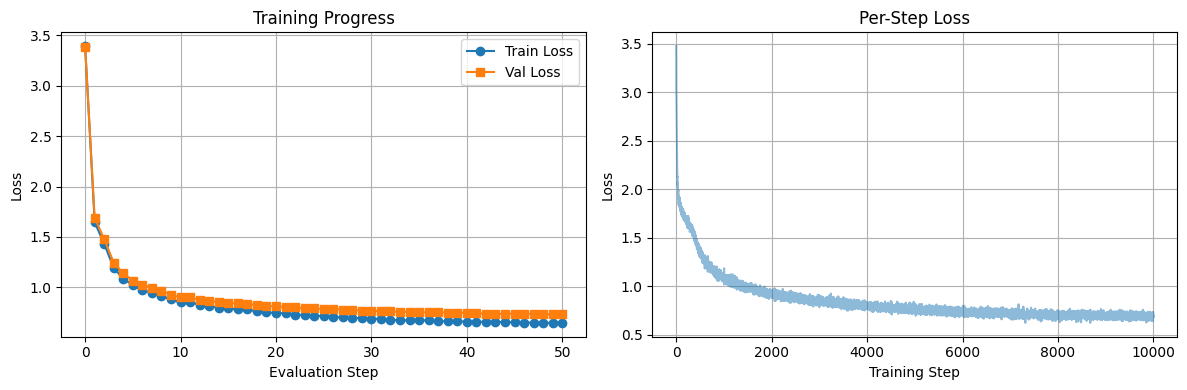

Current train loss: 0.6505
Current val loss: 0.7324
Training iterations: 10000


In [ ]:
# Plot the training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, 'o-', label='Train Loss')
plt.plot(val_losses, 's-', label='Val Loss')
plt.xlabel('Evaluation Step')
plt.ylabel('Loss')
plt.title('Training Progress')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(losses, alpha=0.5)
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.title('Per-Step Loss')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Current train loss: {train_losses[-1]:.4f}")
print(f"Current val loss: {val_losses[-1]:.4f}")
print(f"Training iterations: {len(losses)}")

### generate with untrained model

In [ ]:
model = DrugGPT()
model = model.to(device)

In [ ]:
generated_smiles = []

# Use the correct special tokens from your tokenizer
sos_token = tokenizer.stoi['<START>']  # Use stoi dictionary, not encode
eos_token = tokenizer.stoi['<END>']

print(f"🔍 SOS token: {sos_token} ({tokenizer.itos[sos_token]})")
print(f"🔍 EOS token: {eos_token} ({tokenizer.itos[eos_token]})")

for i in range(10):
    # Vary temperature for diversity
    temp = random.uniform(0.7, 1.2)
    try:
        context = torch.tensor([[sos_token]], dtype=torch.long, device=device)
        generated = model.generate(
            context,
            max_new_tokens=100,
            eos_token=eos_token,
            temperature=temp,
            top_k=random.randint(30, 100)  # Vary top_k too
        )

        # Use tokenizer.decode() instead of decode()
        smi = tokenizer.decode(generated[0].tolist())
        smi = smi.strip()

        if smi and len(smi) > 5:  # Basic length filter
            generated_smiles.append(smi)
            print(f"✅ Generated {i+1}/10: {smi[:50]}...")  # Show first 50 chars
    except Exception as e:
        print(f"⚠️ Error at {i+1}/10: {e}")
        continue

print(f"\n📊 Successfully generated {len(generated_smiles)} molecules")
print(f"\n🔬 Sample molecules:")
for smi in generated_smiles[:5]:
    print(f"  {smi}")

🔍 SOS token: 2 (<START>)
🔍 EOS token: 3 (<END>)
✅ Generated 2/10: 65[Si]2[Se]559[C@@H]C[O][NH3+]3o4\75[NH3+][N+])[N]...
✅ Generated 3/10: [C@@H]1[NH3+]([C@][N-]%11n[nH][nH][C@@]].o[N+]/[Se...
✅ Generated 4/10: [N-]2[C@]%11[C@@H]2]4[[N-]][Se]Cl([I[C@@H][O]371I#...
✅ Generated 5/10: .[C@][Se]]5[C@][N-]5[NH3+][N+]2[O]3BS[N+]34cFCl[C@...
✅ Generated 6/10: [N][O]52([C@@]C3\[C@@H]o6[O-][O][O])OOC%11#[N-][C@...
✅ Generated 7/10: 55%10[NH3+][NH3+][NH3+]B%103CB7.%11[C@]3[C@][C@@H]...
✅ Generated 9/10: [C@]72CF[Si][O-]O5[O-][Se]7C]BOBF/%1092[Si][Si]2F[...
✅ Generated 10/10: [NH3+][C@@]nn/4[N+]3I[N][N-]\[Se]N[N+]1[O-]5BrnS[C...

📊 Successfully generated 8 molecules

🔬 Sample molecules:
  65[Si]2[Se]559[C@@H]C[O][NH3+]3o4\75[NH3+][N+])[N][C@@][C@@])[C@@]9[C@H]N55=.155/%11]
  [C@@H]1[NH3+]([C@][N-]%11n[nH][nH][C@@]].o[N+]/[Se]C[C@H]#4S[N-][O[P/s[C@H][C@@]]41F31s[N-](Cl733Br[Se][NH3+]s[N-]C([N+]=7Po1[C@@][N]o8BCl1\
  [N-]2[C@]%11[C@@H]2]4[[N-]][Se]Cl([I[C@@H][O]371I#8%10Br2%102[N+][Si][N+][N-]3F[N+]

In [ ]:
generated_smiles

['65[Si]2[Se]559[C@@H]C[O][NH3+]3o4\\75[NH3+][N+])[N][C@@][C@@])[C@@]9[C@H]N55=.155/%11]',
 '[C@@H]1[NH3+]([C@][N-]%11n[nH][nH][C@@]].o[N+]/[Se]C[C@H]#4S[N-][O[P/s[C@H][C@@]]41F31s[N-](Cl733Br[Se][NH3+]s[N-]C([N+]=7Po1[C@@][N]o8BCl1\\',
 '[N-]2[C@]%11[C@@H]2]4[[N-]][Se]Cl([I[C@@H][O]371I#8%10Br2%102[N+][Si][N+][N-]3F[N+]][Se]11[C@@H]\\c[O]FC7[O][N-][C@@H]B4[c[C@@][N]Br7]c[C@@H][N]%10',
 '.[C@][Se]]5[C@][N-]5[NH3+][N+]2[O]3BS[N+]34cFCl[C@@][O]I/O[N+]#[Si][C@H]\\[C@@H][Se])/SF[O][[N-]/CI[C@@]\\([O]',
 '[N][O]52([C@@]C3\\[C@@H]o6[O-][O][O])OOC%11#[N-][C@@]2[C@@][C@@][C@@H]ClBr3O(s2]%103[Si][C@H]%11PB])S[O][C@][O][Se]])\\/[C@@]c[C@@][O][Si].F[Si]5',
 '55%10[NH3+][NH3+][NH3+]B%103CB7.%11[C@]3[C@][C@@H]3[C@@]C1F11[N+][Si]/3[C@H]7.F[NH3+]17[O-][C@H]1.Cl[O-][C@]7.(5Cl[C@]P[Se]2)6[N-][Si].%105)[Se]Cl[N+][Se]Cl',
 '[C@]72CF[Si][O-]O5[O-][Se]7C]BOBF/%1092[Si][Si]2F[S+]%10[C@@H]1[NH3+]285%10[NH3+]23%10B785257C[NH3+]75[C@@H]B5[C@H][O-]//[N-][O-]9[N-]OBr[Si]2%10',
 '[NH3+][C@@]nn/4[N+]3I[N][N-]\\[Se

### Load the trained model and generate

In [ ]:
def load_model(checkpoint_path, device=device):
    # Initialize model without hyperparameters, relying on global definitions
    model = DrugGPT()

    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Handle different checkpoint formats
    if isinstance(checkpoint, dict):
        if 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
        else:
            state_dict = checkpoint
    else:
        state_dict = checkpoint.state_dict()

    # Load state dict with strict=False to ignore unexpected keys
    model.load_state_dict(state_dict, strict=False)

    model = model.to(device)
    model.eval()
    return model

In [ ]:
model = load_model("/content/drive/MyDrive/tokenization/improved_drugGPT.pt")

In [ ]:
generated_smiles = []

# Direct dictionary access - THIS IS THE RIGHT WAY
sos_token = tokenizer.stoi['<START>']
eos_token = tokenizer.stoi['<END>']

print(f"🔍 SOS token: {sos_token}")
print(f"🔍 EOS token: {eos_token}")

for i in range(10):
    # Vary temperature for diversity
    temp = random.uniform(0.7, 1.2)
    try:
        context = torch.tensor([[sos_token]], dtype=torch.long, device=device)
        generated = model.generate(
            context,
            max_new_tokens=100,
            eos_token=eos_token,
            temperature=temp,
            top_k=random.randint(30, 100)
        )

        # Use tokenizer.decode() - NOT decode()
        smi = tokenizer.decode(generated[0].tolist())
        smi = smi.strip()

        if smi and len(smi) > 5:
            generated_smiles.append(smi)
            print(f"✅ {i+1}/10: {smi}")
        else:
            print(f"⚠️ {i+1}/10: Generated but too short: '{smi}'")

    except Exception as e:
        print(f"❌ {i+1}/10: Error - {e}")
        continue

print(f"\n📊 Total generated: {len(generated_smiles)} molecules")
print(f"\n🔬 Samples:")
for smi in generated_smiles[:5]:
    print(f"  {smi}")

🔍 SOS token: 2
🔍 EOS token: 3
✅ 1/10: NC1=C(Oc2ccccc2)\N=C(/C=S)\N=C1c3ccccc3
✅ 2/10: CC(C)Cc1ccc2nc(SCC(=O)NN(C(=O)C)c3ccc(F)cc3)sc2c1
✅ 3/10: CCCCCCCCC1CN(CC1)c2ncnc3c2ncn3CCc4nccc(F)c4
✅ 4/10: Cc1ccc(cc1)c2nc3cccnc3c(Nc4cccs4)n2
✅ 5/10: CNC(=O)N1CCN(CC1)c2ccc(cc2)n3cncn3
✅ 6/10: COc1ccc(\C=N\NC(=O)c2ccc(\C=N\NC(=O)c3ccccc3C)c(OC)c2)cc1
✅ 7/10: COc1ccc(NS(=O)(=O)c2ccc(C)cc2C)cc1
✅ 8/10: CC1=C(C2=C(C(=O)O)C(=CC12)c3ccccc3)c4ccccc4
✅ 9/10: CCOC(=O)C1(CCCC1)Nc2ccc(cc2)N3CCCCC3
✅ 10/10: [O-][S+]=C(CSC(=O)c1ccccc1)N2C(=O)CSC2=O

📊 Total generated: 10 molecules

🔬 Samples:
  NC1=C(Oc2ccccc2)\N=C(/C=S)\N=C1c3ccccc3
  CC(C)Cc1ccc2nc(SCC(=O)NN(C(=O)C)c3ccc(F)cc3)sc2c1
  CCCCCCCCC1CN(CC1)c2ncnc3c2ncn3CCc4nccc(F)c4
  Cc1ccc(cc1)c2nc3cccnc3c(Nc4cccs4)n2
  CNC(=O)N1CCN(CC1)c2ccc(cc2)n3cncn3


In [ ]:
generated_smiles

['NC1=C(Oc2ccccc2)\\N=C(/C=S)\\N=C1c3ccccc3',
 'CC(C)Cc1ccc2nc(SCC(=O)NN(C(=O)C)c3ccc(F)cc3)sc2c1',
 'CCCCCCCCC1CN(CC1)c2ncnc3c2ncn3CCc4nccc(F)c4',
 'Cc1ccc(cc1)c2nc3cccnc3c(Nc4cccs4)n2',
 'CNC(=O)N1CCN(CC1)c2ccc(cc2)n3cncn3',
 'COc1ccc(\\C=N\\NC(=O)c2ccc(\\C=N\\NC(=O)c3ccccc3C)c(OC)c2)cc1',
 'COc1ccc(NS(=O)(=O)c2ccc(C)cc2C)cc1',
 'CC1=C(C2=C(C(=O)O)C(=CC12)c3ccccc3)c4ccccc4',
 'CCOC(=O)C1(CCCC1)Nc2ccc(cc2)N3CCCCC3',
 '[O-][S+]=C(CSC(=O)c1ccccc1)N2C(=O)CSC2=O']

In [ ]:
## check validity :

vals = []

for s in generated_smiles:
    v = check_validity(s)
    if v:
        vals.append(s)

print((len(vals) / len(generated_smiles) ) *100, "%")

100.0 %


In [ ]:
print("\n1. Checking validity...")
valid_smiles = check_validity_batch(generated_smiles)
validity = len(valid_smiles) / len(generated_smiles) if generated_smiles else 0
print(f"Valid molecules: {len(valid_smiles)}/{len(generated_smiles)} ({validity:.2%})")


1. Checking validity...
Valid molecules: 10/10 (100.00%)


In [ ]:
print("\n2. Checking uniqueness...")
unique_smiles = check_uniqueness_correct(valid_smiles)
uniqueness = len(unique_smiles) / len(valid_smiles) if valid_smiles else 0
print(f"Unique molecules: {len(unique_smiles)}/{len(valid_smiles)} ({uniqueness:.2%})")


2. Checking uniqueness...
Unique molecules: 10/10 (100.00%)


In [ ]:
# 3. Novelty (CORRECTED)
print("\n3. Checking novelty...")
if training_smiles:
        novel_smiles = check_novelty_correct(unique_smiles, training_smiles)
        novelty = len(novel_smiles) / len(unique_smiles) if unique_smiles else 0
        print(f"Novel molecules: {len(novel_smiles)}/{len(unique_smiles)} ({novelty:.2%})")
else:
        print("Warning: No training data loaded for novelty check")
        novel_smiles = unique_smiles
        novelty = 1.0


3. Checking novelty...
Novel molecules: 10/10 (100.00%)


In [ ]:
# 4. Diversity
print("\n4. Calculating diversity...")
if len(novel_smiles) > 1:
        diversity = calculate_diversity_tanimoto(novel_smiles)
        print(f"Internal diversity: {diversity:.4f}")
else:
        diversity = 0.0
        print("Not enough molecules for diversity calculation")

# 5. Drug-likeness (Lipinski's Rule of Five)
print("\n5. Checking drug-likeness...")
drug_like_count = 0
for smi in novel_smiles:
     try:
        mol = Chem.MolFromSmiles(smi)
        if mol:
           mw = Descriptors.MolWt(mol)
           logp = Descriptors.MolLogP(mol)
           hbd = Descriptors.NumHDonors(mol)
           hba = Descriptors.NumHAcceptors(mol)

           # Lipinski's Rule of Five
           if mw <= 500 and logp <= 5 and hbd <= 5 and hba <= 10:
              drug_like_count += 1
     except:
            continue

drug_likeness = drug_like_count / len(novel_smiles) if novel_smiles else 0
print(f"Drug-like molecules: {drug_like_count}/{len(novel_smiles)} ({drug_likeness:.2%})")

# Summary
print("\n" + "="*50)
print("BENCHMARK SUMMARY")
print("="*50)
print(f"Validity:      {validity:.2%}")
print(f"Uniqueness:    {uniqueness:.2%}")
print(f"Novelty:       {novelty:.2%}")
print(f"Diversity:     {diversity:.4f}")
print(f"Drug-likeness: {drug_likeness:.2%}")
print("="*50)


4. Calculating diversity...
Internal diversity: 0.9170

5. Checking drug-likeness...
Drug-like molecules: 9/10 (90.00%)

BENCHMARK SUMMARY
Validity:      100.00%
Uniqueness:    100.00%
Novelty:       100.00%
Diversity:     0.9170
Drug-likeness: 90.00%


[22:50:50] DEPRECATION WARNING: please use MorganGenerator
[22:50:50] DEPRECATION WARNING: please use MorganGenerator
[22:50:50] DEPRECATION WARNING: please use MorganGenerator
[22:50:50] DEPRECATION WARNING: please use MorganGenerator
[22:50:50] DEPRECATION WARNING: please use MorganGenerator
[22:50:50] DEPRECATION WARNING: please use MorganGenerator
[22:50:50] DEPRECATION WARNING: please use MorganGenerator
[22:50:50] DEPRECATION WARNING: please use MorganGenerator
[22:50:50] DEPRECATION WARNING: please use MorganGenerator
[22:50:50] DEPRECATION WARNING: please use MorganGenerator
